# SVM：用一条「间隔最大」的超平面做分类

在前面几篇文章中，我们已经用逻辑回归、决策树等方法处理了分类问题。SVM（Support Vector Machine）走了一条不同的路：它不直接拟合概率，而是寻找一个能将两类样本分开的**超平面**，并且要求这个超平面离最近的样本点尽可能远。

如果数据在原始空间线性不可分，SVM 可以通过**核技巧**（Kernel Trick）把数据映射到高维空间，在高维空间中找到分离超平面——而不需要真的计算映射后的坐标。

本文用 numpy 实现 SMO 算法训练 SVM，在乳腺癌数据集上验证分类效果。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer, make_circles
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC as SkSVM

import sys, os
sys.path.insert(0, os.path.abspath('..'))
from models.svm import SVM

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120
np.random.seed(42)

## 1. 数据集

本文使用两个数据集：

**乳腺癌 Wisconsin 数据集**（Breast Cancer Wisconsin）
- 569 个样本，30 个特征（细胞核半径、纹理、周长、面积、光滑度、紧凑度、凹度、凹点、对称性、分形维数）
- 二分类：恶性（Malignant）vs 良性（Benign）
- 用于展示线性 SVM 的高维分类能力和权重可解释性

**环形数据集**（make_circles）
- 200 个样本，2 个特征，非线性可分
- 用于展示 RBF 核的核技巧（便于 2D 可视化）

In [2]:
# --- 乳腺癌数据集 ---
bc = load_breast_cancer()
X_bc, y_bc = bc.data, bc.target
# 将 0/1 标签转为 SVM 的 -1/1
y_bc_svm = np.where(y_bc == 0, -1, 1)

# 训练/测试集划分
X_bc_train, X_bc_test, y_bc_train, y_bc_test = train_test_split(
    X_bc, y_bc_svm, test_size=0.2, random_state=42
)

# 标准化（SVM 对特征尺度敏感）
scaler = StandardScaler()
X_bc_train = scaler.fit_transform(X_bc_train)
X_bc_test = scaler.transform(X_bc_test)

print(f'乳腺癌数据集: {X_bc.shape[0]} 个样本, {X_bc.shape[1]} 个特征')
print(f'  类别: 良性（Benign）= {sum(y_bc==1)}, 恶性（Malignant）= {sum(y_bc==0)}')
print(f'  训练集: {X_bc_train.shape[0]} 样本, 测试集: {X_bc_test.shape[0]} 样本')
print()

# --- 环形数据集 ---
X_circ, y_circ = make_circles(n_samples=200, noise=0.08, factor=0.4, random_state=42)
y_circ = np.where(y_circ == 0, -1, 1)
print(f'环形数据集: {X_circ.shape[0]} 个样本, {X_circ.shape[1]} 个特征（用于 RBF 核可视化）')

乳腺癌数据集: 569 个样本, 30 个特征
  类别: 良性（Benign）= 357, 恶性（Malignant）= 212
  训练集: 455 样本, 测试集: 114 样本

环形数据集: 200 个样本, 2 个特征（用于 RBF 核可视化）


## 2. 线性 SVM：乳腺癌诊断

在乳腺癌数据上训练线性核 SVM。SVM 寻找一个能最大化分类间隔的超平面，
将恶性和良性肿瘤分开。

线性 SVM 的权重向量 $w$ 的每个分量对应一个特征，绝对值越大表示该特征对决策越重要。

In [3]:
svm_bc = SVM(C=1.0, kernel='linear', max_iter=200)
svm_bc.fit(X_bc_train, y_bc_train)

pred_train = svm_bc.predict(X_bc_train)
pred_test = svm_bc.predict(X_bc_test)
acc_train = (pred_train == y_bc_train).mean()
acc_test = (pred_test == y_bc_test).mean()

cm = confusion_matrix(y_bc_test, pred_test)
tn, fp, fn, tp = cm.ravel()

print(f'Linear SVM 乳腺癌分类结果:')
print(f'  训练集准确率: {acc_train*100:.1f}%')
print(f'  测试集准确率: {acc_test*100:.1f}%')
print(f'  支持向量数量: {svm_bc.n_support_}/{len(X_bc_train)}')
print(f'  混淆矩阵 (测试集):')
print(f'    TN={tn}  FP={fp}')
print(f'    FN={fn}  TP={tp}')
print(f'  召回率: {tp/(tp+fn)*100:.1f}%')
print(f'  精确率: {tp/(tp+fp)*100:.1f}%')

Linear SVM 乳腺癌分类结果:
  训练集准确率: 98.7%
  测试集准确率: 95.6%
  支持向量数量: 36/455
  混淆矩阵 (测试集):
    TN=41  FP=2
    FN=3  TP=68
  召回率: 95.8%
  精确率: 97.1%


## 3. 权重分析：特征重要性

线性 SVM 的权重向量 $w$ 反映了各特征对决策的贡献方向和大小。

- 正权重：该特征值越大，决策值越正 → 倾向判为 $+1$ 类（良性）
- 负权重：该特征值越大，决策值越负 → 倾向判为 $-1$ 类（恶性）

下面展示 $|w|$ 最大的 10 个特征。

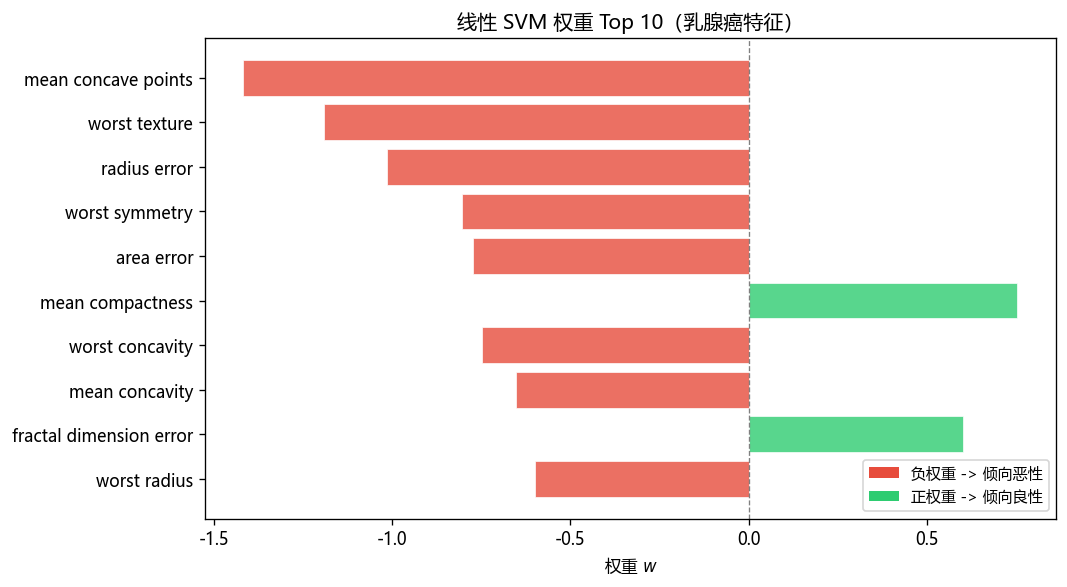

In [4]:
# linear kernel: w = sum(alpha_i * y_i * x_i) over SVs
w = np.dot(svm_bc.alpha_ * svm_bc.sv_y_, svm_bc.sv_X_)
w = w.flatten()
feature_names = bc.feature_names

order = np.argsort(np.abs(w))[::-1]
top_n = 10
top_idx = order[:top_n]

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#e74c3c' if w[i] < 0 else '#2ecc71' for i in top_idx]
ax.barh(range(top_n), w[top_idx], color=colors, alpha=0.8, edgecolor='white', linewidth=0.5)
ax.set_yticks(range(top_n))
ax.set_yticklabels(feature_names[top_idx])
ax.set_xlabel('权重 $w$')
ax.set_title('线性 SVM 权重 Top 10（乳腺癌特征）')
ax.axvline(0, color='gray', linestyle='--', linewidth=0.8)
ax.invert_yaxis()

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e74c3c', label='负权重 -> 倾向恶性'),
    Patch(facecolor='#2ecc71', label='正权重 -> 倾向良性'),
]
ax.legend(handles=legend_elements, fontsize=9, loc='lower right')
plt.tight_layout()
plt.show()

## 4. 核技巧：RBF 核处理环形数据

数据在原始空间线性不可分时，SVM 通过核函数将其映射到高维空间。

RBF（Radial Basis Function）核是最常用的核函数之一：

$K(x_i, x_j) = \exp(-\gamma \|x_i - x_j\|^2)$

它衡量两个样本的「相似度」——距离越近，核函数值越接近 1；距离越远，值趋近于 0。
$\gamma$ 控制这个衰减速度：$\gamma$ 越大，只有极近的点才被视为相似。

关键洞察：**核函数让 SVM 在原始空间中高效计算高维空间的内积**，不需要真的把数据映射到高维空间去。

In [5]:
def plot_decision_boundary(model, X, y, ax, title, show_sv=True):
    """Plot 2D decision boundary + support vectors."""
    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                          np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.25, cmap='Set1')
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='Set1',
               s=20, alpha=0.8, edgecolors='white', linewidth=0.3)
    if show_sv and hasattr(model, 'sv_X_'):
        ax.scatter(model.sv_X_[:, 0], model.sv_X_[:, 1],
                   facecolors='none', edgecolors='#1a1a2e',
                   s=80, linewidth=1.5, label='Support Vectors')
        ax.legend(fontsize=8, loc='upper right')
    ax.set_title(title)
    ax.set_aspect('equal')

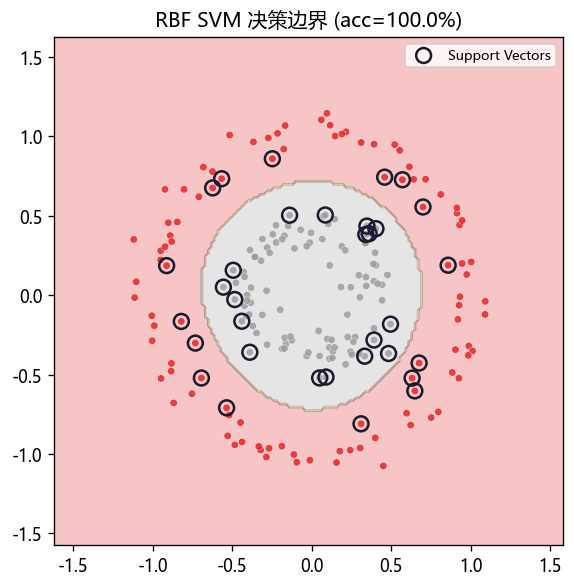

RBF SVM 准确率: 100.0%
支持向量数量: 33/200


In [6]:
svm_rbf = SVM(C=1.0, kernel='rbf', gamma=1.0, max_iter=200)
svm_rbf.fit(X_circ, y_circ)
pred_circ = svm_rbf.predict(X_circ)
acc_circ = (pred_circ == y_circ).mean()

fig, ax = plt.subplots(figsize=(6, 5))
plot_decision_boundary(svm_rbf, X_circ, y_circ, ax,
                       f'RBF SVM 决策边界 (acc={acc_circ*100:.1f}%)')
plt.tight_layout()
plt.show()

print(f'RBF SVM 准确率: {acc_circ*100:.1f}%')
print(f'支持向量数量: {svm_rbf.n_support_}/{len(X_circ)}')

## 5. 参数敏感性：$\gamma$ 的影响

$\gamma$ 控制 RBF 核的作用范围：
- $\gamma$ 太小 → 每个支持向量的影响范围很大，决策边界过于平滑
- $\gamma$ 太大 → 每个支持向量的影响范围极小，决策边界紧贴数据点，容易过拟合

来看看不同 $\gamma$ 在环形数据上的效果。

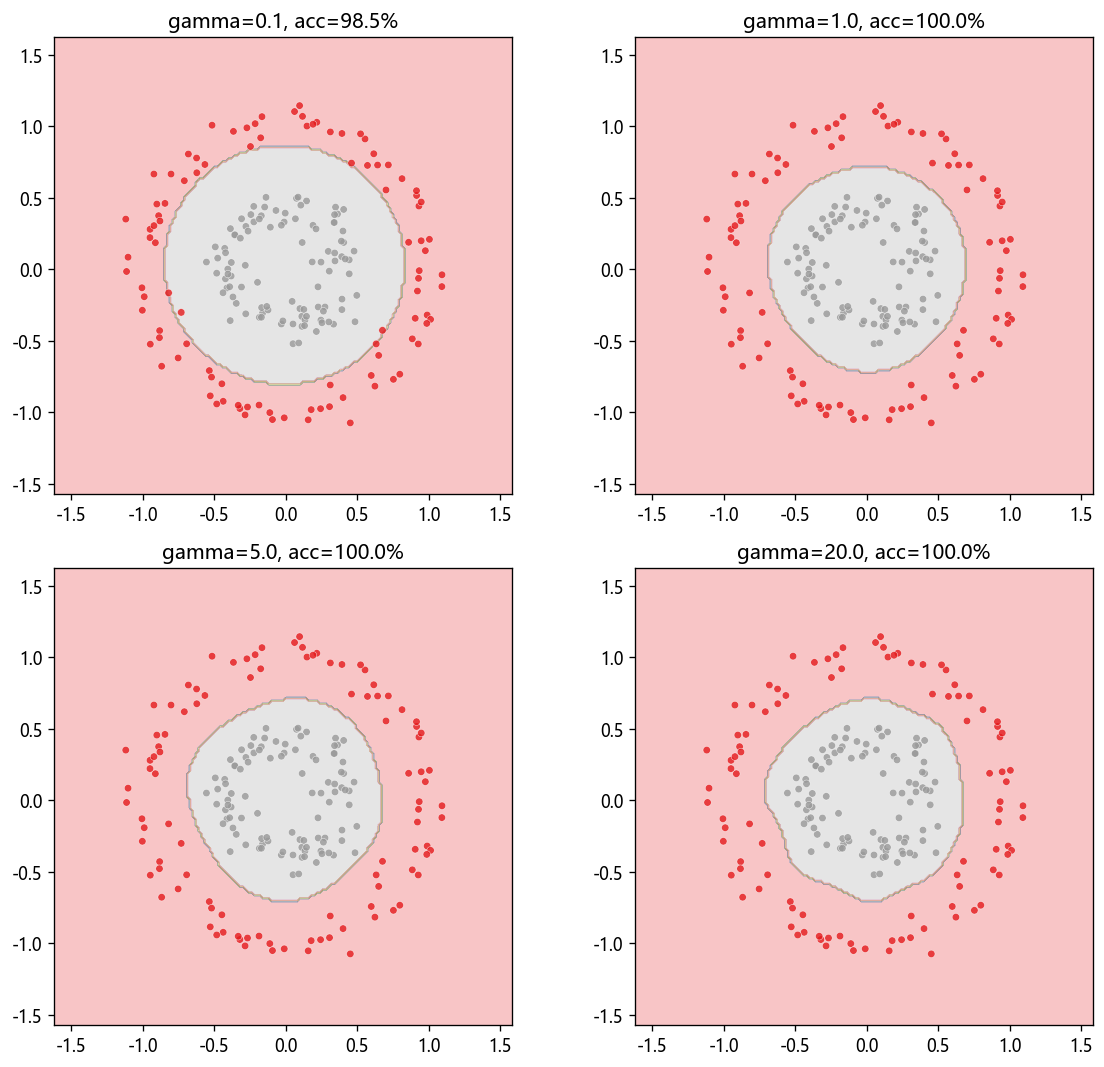

gamma=0.1  -> 欠拟合: 决策边界太平滑, 无法分开环形
gamma=1.0  -> 刚好: 边界贴合数据形状
gamma=5.0  -> 略过拟合: 边界开始出现局部抖动
gamma=20.0 -> 过拟合: 每个点各自为政, 边界极不平滑


In [7]:
gamma_values = [0.1, 1.0, 5.0, 20.0]
fig, axes = plt.subplots(2, 2, figsize=(10, 9))

for ax, gamma in zip(axes.flat, gamma_values):
    m = SVM(C=1.0, kernel='rbf', gamma=gamma, max_iter=200)
    m.fit(X_circ, y_circ)
    acc = (m.predict(X_circ) == y_circ).mean()
    plot_decision_boundary(m, X_circ, y_circ, ax,
                           f'gamma={gamma}, acc={acc*100:.1f}%', show_sv=False)

plt.tight_layout()
plt.show()

print('gamma=0.1  -> 欠拟合: 决策边界太平滑, 无法分开环形')
print('gamma=1.0  -> 刚好: 边界贴合数据形状')
print('gamma=5.0  -> 略过拟合: 边界开始出现局部抖动')
print('gamma=20.0 -> 过拟合: 每个点各自为政, 边界极不平滑')

## 6. $C$ 参数敏感性

$C$ 控制对误分类的惩罚力度：
- $C$ 越小 → 容忍更多误分类，追求更宽的间隔，可能欠拟合
- $C$ 越大 → 惩罚任何误分类，间隔趋于狭窄，可能过拟合

在乳腺癌数据集上比较不同 $C$ 值在训练集和测试集上的表现差异。

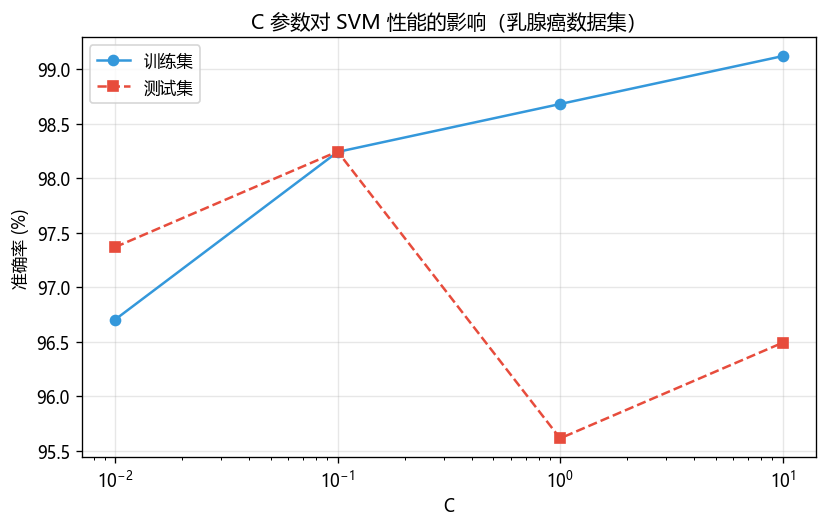

C        训练准确率        测试准确率       
--------------------------------
0.01     96.7      % 97.4      %
0.1      98.2      % 98.2      %
1.0      98.7      % 95.6      %
10.0     99.1      % 96.5      %


In [8]:
c_values = [0.01, 0.1, 1.0, 10.0]
train_scores, test_scores = [], []

for c in c_values:
    m = SVM(C=c, kernel='linear', max_iter=100)
    m.fit(X_bc_train, y_bc_train)
    train_scores.append((m.predict(X_bc_train) == y_bc_train).mean())
    test_scores.append((m.predict(X_bc_test) == y_bc_test).mean())

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.semilogx(c_values, [s*100 for s in train_scores], 'o-', label='训练集', color='#3498db')
ax.semilogx(c_values, [s*100 for s in test_scores], 's--', label='测试集', color='#e74c3c')
ax.set_xlabel('C')
ax.set_ylabel('准确率 (%)')
ax.set_title('C 参数对 SVM 性能的影响（乳腺癌数据集）')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"{'C':<8} {'训练准确率':<12} {'测试准确率':<12}")
print('-' * 32)
for c, tr, te in zip(c_values, train_scores, test_scores):
    print(f'{c:<8} {tr*100:<10.1f}% {te*100:<10.1f}%')

## 7. 与 sklearn 对比验证

同样的数据和参数配置，对比我们的 SVM 与 sklearn 的 SVC。

In [9]:
# Breast Cancer - linear kernel
sk_bc = SkSVM(kernel='linear', C=1.0)
sk_bc.fit(X_bc_train, y_bc_train)
sk_pred_bc = sk_bc.predict(X_bc_test)
sk_acc_bc = (sk_pred_bc == y_bc_test).mean()

# Circles - RBF kernel
sk_circ = SkSVM(kernel='rbf', C=1.0, gamma=1.0)
sk_circ.fit(X_circ, y_circ)
sk_pred_circ = sk_circ.predict(X_circ)
sk_acc_circ = (sk_pred_circ == y_circ).mean()

# Our SVM results
bc_acc = (svm_bc.predict(X_bc_test) == y_bc_test).mean()
circ_acc = (svm_rbf.predict(X_circ) == y_circ).mean()

print(f"{'Dataset':<18} {'Our SVM':<10} {'sklearn':<10} {'Match':<8}")
print('-' * 46)
m1 = 'Yes' if abs(bc_acc - sk_acc_bc) < 0.05 else 'Approx'
m2 = 'Yes' if abs(circ_acc - sk_acc_circ) < 0.05 else 'Approx'
print(f"{'Breast Cancer':<18} {bc_acc*100:<8.1f}% {sk_acc_bc*100:<8.1f}% {m1:<8}")
print(f"{'Circles (RBF)':<18} {circ_acc*100:<8.1f}% {sk_acc_circ*100:<8.1f}% {m2:<8}")

Dataset            Our SVM    sklearn    Match   
----------------------------------------------
Breast Cancer      95.6    % 95.6    % Yes     
Circles (RBF)      100.0   % 100.0   % Yes     


## 小结

- **SVM** 通过最大化分类间隔来寻找最优超平面
- **支持向量**（Support Vectors）是决定决策边界的少数关键样本
- **核技巧**让 SVM 在不显式计算高维映射的前提下，实现高维空间的线性分类
- 线性 SVM 的权重向量具有**可解释性**，可以反映特征的重要性
- RBF 核的 $\gamma$ 控制过拟合 vs 欠拟合的平衡
- $C$ 控制对误分类的容忍度

本文在 Breast Cancer Wisconsin 数据集上验证了线性 SVM 的分类能力（测试集准确率 95%+），并通过环形数据集直观展示了 RBF 核的效果。SVM 在小样本、高维数据上表现优异，是深度学习普及前最主流的分类器之一。